# Pan-Cancer Gene Expression — Exploratory Data Analysis

Inspects the raw (continuous) gene expression matrix from the TCGA pan-cancer dataset.  
**2 617 tumour samples · 1 247 genes · 12 cancer types.**

Typical things to look for in cancer expression data:
- Sample-level outliers (globally very high or low total expression)
- Low-variance / near-zero-expression genes that add noise
- Whether the data is already (log-)normalized
- Cancer-type-specific expression programmes (differential expression)
- How many principal components capture most variance
- Whether cancer types form distinct clusters in low-dimensional space
- Which cancer types are most similar in their transcriptional profiles
- Expression-based patient stratification proxies


## 1 · Load and Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", font_scale=1.1)

GE_FILE = "pan_cancer/gene_expression.csv"
CT_FILE = "pan_cancer/cancertype.csv"

ge = pd.read_csv(GE_FILE, index_col=0)   # (N, n_genes) — log2 expression, already centred
ct = pd.read_csv(CT_FILE, index_col=0)   # (N,) cancer type label

cancer_types = sorted(ct["cancertype"].unique())
ct_palette   = sns.color_palette("tab20", len(cancer_types))
ct_color     = {t: ct_palette[i] for i, t in enumerate(cancer_types)}

print(f"Samples  : {ge.shape[0]}")
print(f"Genes    : {ge.shape[1]}")
print(f"Cancer types ({len(cancer_types)}): {cancer_types}")
print(f"\nExpression range: {ge.values.min():.3f}  to  {ge.values.max():.3f}")
print(f"Global mean: {ge.values.mean():.4f},  std: {ge.values.std():.4f}")
print()
print("Cancer-type sample counts:")
print(ct["cancertype"].value_counts().to_string())
print()
ge.head(3)


Samples  : 2617
Genes    : 1247
Cancer types (12): ['BLCA', 'BRCA', 'COAD', 'GBM', 'HNSC', 'KIRC', 'LAML', 'LUAD', 'LUSC', 'OV', 'READ', 'UCEC']

Expression range: -13.617  to  13.670
Global mean: -0.0440,  std: 1.3750

Cancer-type sample counts:
cancertype
BRCA    480
KIRC    404
HNSC    295
UCEC    235
LUAD    229
OV      213
LUSC    179
LAML    162
COAD    158
GBM     101
BLCA     95
READ     66



,A1BG,ABCB9,ACADS,ACBD4,ACBD6,ACP1,ACTR3B,ADAM28,ADAMDEC1,ADAMTS2,...,ZNF703,ZNF710,ZNF74,ZNF750,ZNF837,ZNF84,ZNF879,ZNRF3,ZSCAN18,ZZEF1
TCGA.BL.A0C8.01A.11R.A10U.07,-2.533269,-0.30,1.039363,-0.270215,-0.67,0.13,0.04,-3.12,-3.88,1.27,...,-1.07,-0.608,-0.022319,2.827999,-0.70,-0.388685,1.162997,-0.58,0.00,0.290227
TCGA.BL.A13I.01A.11R.A13Y.07,0.106731,-0.32,0.459363,-0.230215,0.36,-0.08,-0.24,1.11,3.05,-1.16,...,-0.71,-0.288,0.537680,-4.402001,-0.68,-1.338685,-1.827004,-0.96,-2.48,0.260227
TCGA.BL.A13J.01A.11R.A10U.07,-1.303269,0.02,0.029363,0.359785,1.13,-0.14,-0.24,-3.39,-0.17,1.22,...,0.15,-0.408,-0.222320,4.847999,-0.84,-0.238685,-1.767003,-0.78,-1.73,-1.179773


## 2 · Basic Expression Statistics

Per-sample and per-gene summaries. A boxplot of total (sum) expression per sample is a quick outlier screen — samples with anomalously low totals may be failed libraries.

Per-gene statistics (first 5):
           mean       std  variance       min       max
A1BG  -0.119230  1.403247  1.969101 -4.123270  4.582730
ABCB9 -0.088023  1.019761  1.039913 -4.510000  4.736000
ACADS  0.127896  1.136367  1.291331 -5.040637  3.510000
ACBD4 -0.088037  1.167492  1.363037 -4.420215  3.269785
ACBD6 -0.002098  0.535671  0.286943 -2.134931  2.020000

Overall per-gene variance: min=0.1231, median=1.0161, max=15.7973


C:\Users\jonanord\AppData\Local\Temp\ipykernel_1344\1539111045.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=order, patch_artist=True, medianprops=dict(color="black"))


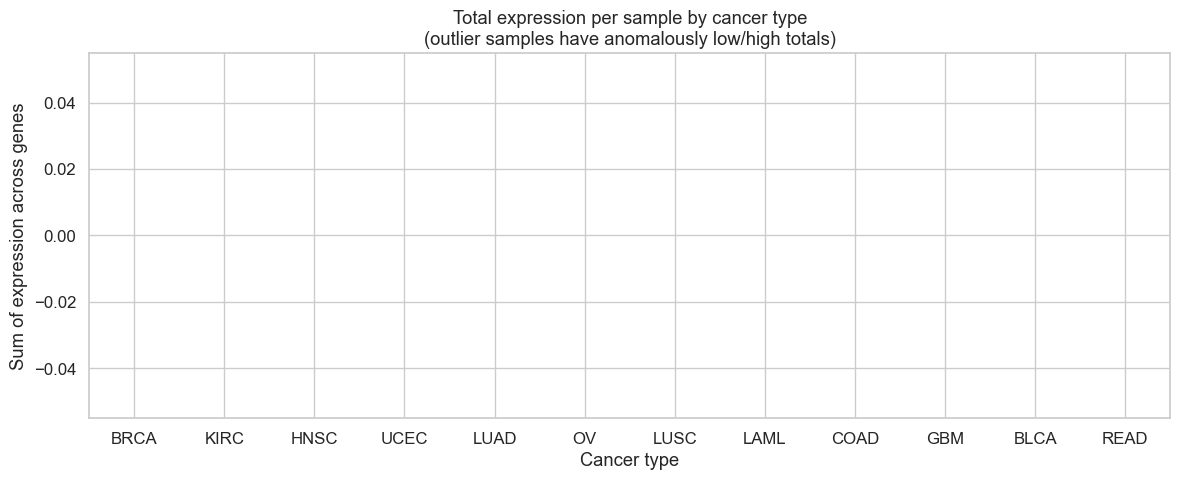

In [2]:
# Per-gene summary
gene_stats = pd.DataFrame({
    "mean":     ge.mean(axis=0),
    "std":      ge.std(axis=0),
    "variance": ge.var(axis=0),
    "min":      ge.min(axis=0),
    "max":      ge.max(axis=0),
})
print("Per-gene statistics (first 5):")
print(gene_stats.head().to_string())
print(f"\nOverall per-gene variance: min={gene_stats['variance'].min():.4f}, "
      f"median={gene_stats['variance'].median():.4f}, max={gene_stats['variance'].max():.4f}")

# Per-sample summary
sample_stats = pd.DataFrame({
    "mean":     ge.mean(axis=1),
    "std":      ge.std(axis=1),
    "sum":      ge.sum(axis=1),
    "cancer":   ct["cancertype"],
})

# Boxplot: total expression per sample, grouped by cancer type
fig, ax = plt.subplots(figsize=(12, 5))
order = ct["cancertype"].value_counts().index.tolist()
data_by_type = [sample_stats.loc[sample_stats["cancer"] == t, "sum"].values for t in order]
bp = ax.boxplot(data_by_type, labels=order, patch_artist=True, medianprops=dict(color="black"))
for patch, t in zip(bp["boxes"], order):
    patch.set_facecolor(ct_color[t])
ax.set_xlabel("Cancer type")
ax.set_ylabel("Sum of expression across genes")
ax.set_title("Total expression per sample by cancer type\n(outlier samples have anomalously low/high totals)")
plt.tight_layout()
plt.show()


## 3 · Missing Values and Quality Control

- Check for NaN / infinite values.  
- Flag near-constant genes (variance < threshold) — they carry no discriminatory signal.  
- The data appear to already be log-normalized (range ≈ −14 to +14, mean ≈ 0); we verify this and skip re-normalization if confirmed.

NaN entries : 0
Inf entries : 0

Genes with variance < 0.01: 0 / 1247


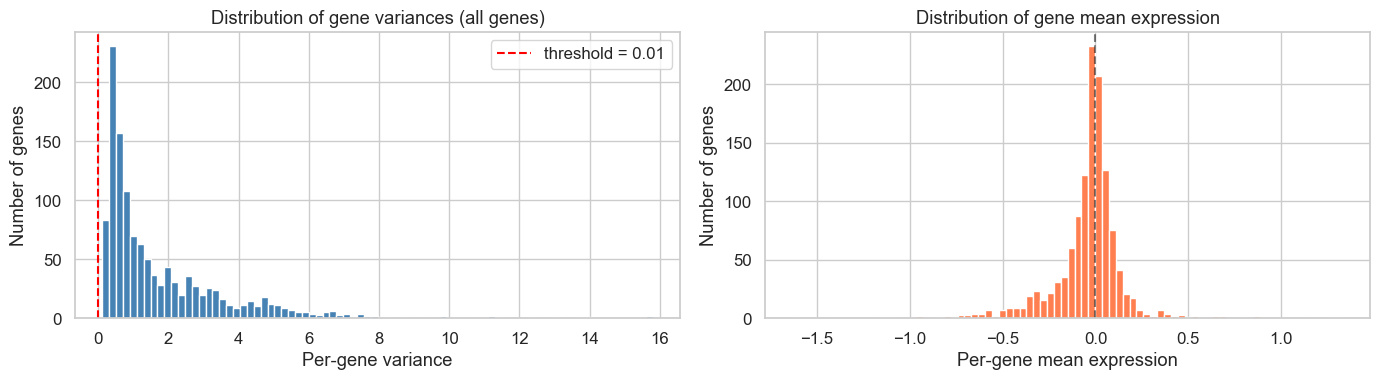


Global mean ≈ -0.0440 → data appear already centred/log-normalised.
After low-variance filter: 1247 genes retained.


In [3]:
n_nan  = ge.isna().sum().sum()
n_inf  = np.isinf(ge.values).sum()
print(f"NaN entries : {n_nan}")
print(f"Inf entries : {n_inf}")

# Near-constant gene filter
VAR_THRESHOLD = 0.01
low_var_mask = gene_stats["variance"] < VAR_THRESHOLD
print(f"\nGenes with variance < {VAR_THRESHOLD}: {low_var_mask.sum()} / {ge.shape[1]}")

# Histogram of per-gene variance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(gene_stats["variance"], bins=80, color="steelblue", edgecolor="white")
ax.axvline(VAR_THRESHOLD, color="red", linestyle="--", label=f"threshold = {VAR_THRESHOLD}")
ax.set_xlabel("Per-gene variance")
ax.set_ylabel("Number of genes")
ax.set_title("Distribution of gene variances (all genes)")
ax.legend()

ax = axes[1]
ax.hist(gene_stats["mean"], bins=80, color="coral", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Per-gene mean expression")
ax.set_ylabel("Number of genes")
ax.set_title("Distribution of gene mean expression")

plt.tight_layout()
plt.show()

# Confirm data is already zero-centred / log-normalised
print(f"\nGlobal mean ≈ {ge.values.mean():.4f} → data appear already centred/log-normalised.")
ge_filt = ge.loc[:, ~low_var_mask]
print(f"After low-variance filter: {ge_filt.shape[1]} genes retained.")


## 4 · Expression Distribution per Cancer Type

Violin plots show the full shape of the expression distribution within each cancer type. Cancer types whose median or spread differs substantially may have distinct normalization levels or genuinely different transcriptional states.

C:\Users\jonanord\AppData\Local\Temp\ipykernel_1344\3688956542.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(cancer=ct["cancertype"].values)
C:\Users\jonanord\AppData\Local\Temp\ipykernel_1344\3688956542.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


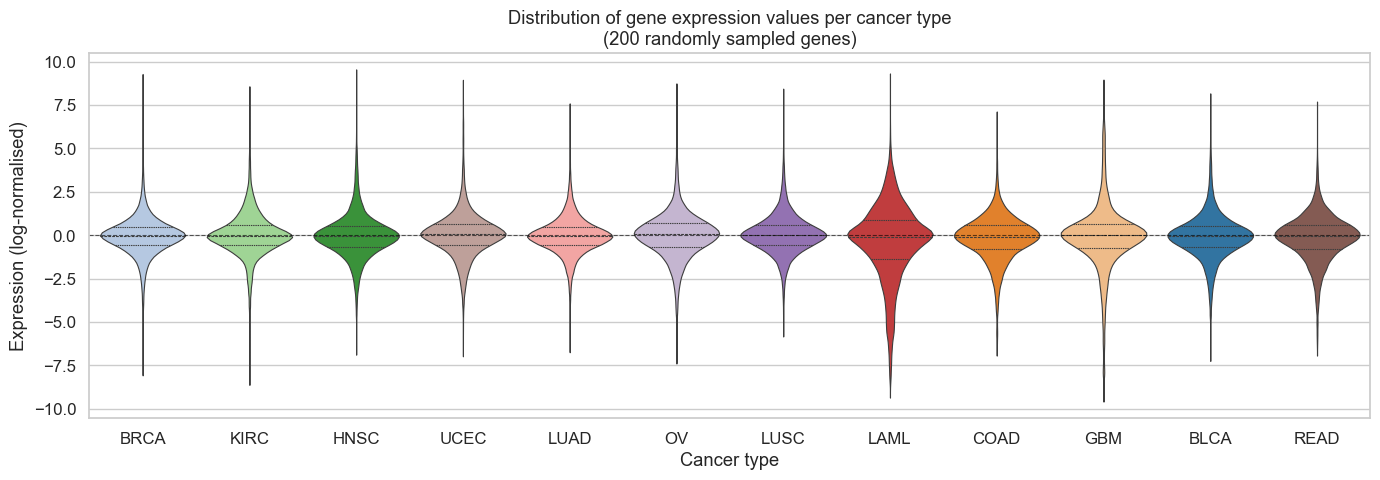

Per-cancer-type global median expression:
cancer
UCEC    0.085732
KIRC    0.068925
LUSC    0.034552
LUAD    0.011753
OV     -0.008130
BRCA   -0.047337
GBM    -0.048177
BLCA   -0.078653
HNSC   -0.079992
READ   -0.146337
COAD   -0.174529
LAML   -0.454719


C:\Users\jonanord\AppData\Local\Temp\ipykernel_1344\3688956542.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  medians = ge.assign(cancer=ct["cancertype"].values).groupby("cancer").median()


In [4]:
# Melt to long form for seaborn (subsample genes to keep it manageable)
rng = np.random.default_rng(42)
gene_sample = rng.choice(ge.columns, size=min(200, ge.shape[1]), replace=False)
ge_long = (
    ge[gene_sample]
    .assign(cancer=ct["cancertype"].values)
    .melt(id_vars="cancer", var_name="gene", value_name="expression")
)

fig, ax = plt.subplots(figsize=(14, 5))
order = ct["cancertype"].value_counts().index.tolist()
sns.violinplot(
    data=ge_long, x="cancer", y="expression", order=order,
    palette=ct_color, inner="quartile", linewidth=0.8, ax=ax
)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Cancer type")
ax.set_ylabel("Expression (log-normalised)")
ax.set_title("Distribution of gene expression values per cancer type\n(200 randomly sampled genes)")
plt.tight_layout()
plt.show()

# Per-cancer median expression profile
medians = ge.assign(cancer=ct["cancertype"].values).groupby("cancer").median()
print("Per-cancer-type global median expression:")
print(medians.mean(axis=1).sort_values(ascending=False).to_string())


## 5 · Highly Variable Genes (HVGs)

Genes with high variance relative to their mean carry the most biological signal. We plot the **mean–variance trend** and select the top HVGs by standardised variance (variance / mean, clipped to remove outliers). These HVGs are used in all downstream analyses.

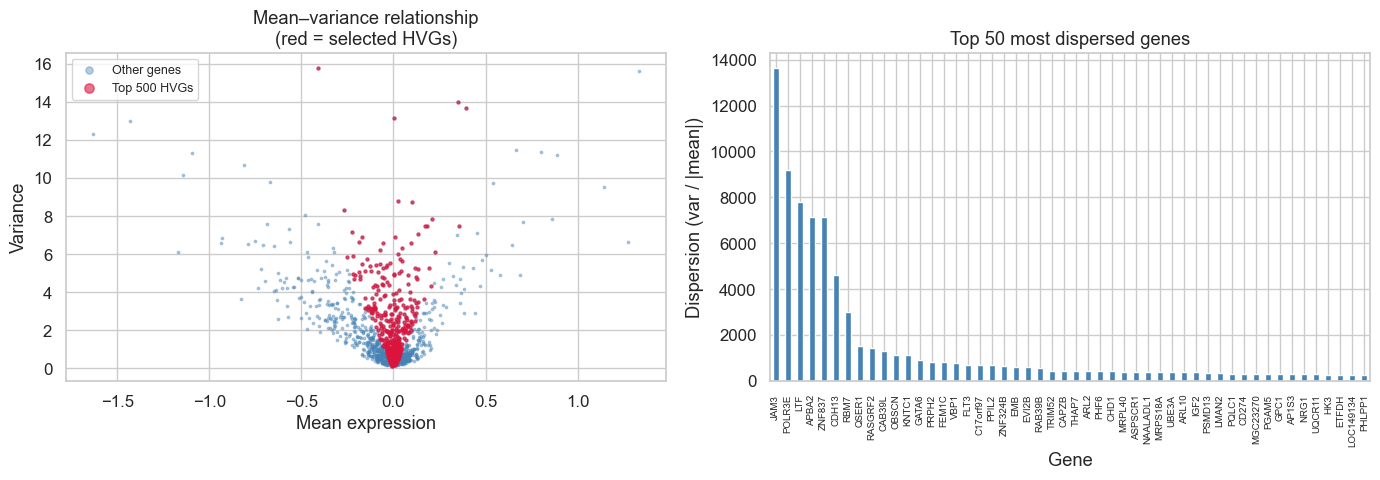

HVG matrix shape: (2617, 500)
Top 20 HVGs by dispersion:
JAM3        13619.095013
POLR3E       9172.619448
LTF          7783.685579
APBA2        7161.273908
ZNF837       7139.364018
CDH13        4604.926928
RBM7         2984.120374
QSER1        1532.081751
RASGRF2      1430.037553
CAB39L       1298.270229
OBSCN        1143.853851
KNTC1        1120.087179
GATA6         898.465813
PRPH2         847.488177
FEM1C         807.186514
VBP1          779.358730
FLT3          703.247133
C17orf97      694.819237
PPIL2         689.366417
ZNF324B       670.011495


In [5]:
N_HVG = 500   # number of highly variable genes to retain

gene_mean = ge_filt.mean(axis=0)
gene_var  = ge_filt.var(axis=0)
# Dispersion: variance / (|mean| + 1e-6) to avoid division by near-zero means
dispersion = gene_var / (gene_mean.abs() + 1e-6)

hvg_idx   = dispersion.nlargest(N_HVG).index
ge_hvg    = ge_filt[hvg_idx]

# Mean–variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(gene_mean, gene_var, s=3, alpha=0.4, color="steelblue", label="Other genes")
ax.scatter(gene_mean[hvg_idx], gene_var[hvg_idx], s=5, alpha=0.6, color="crimson", label=f"Top {N_HVG} HVGs")
ax.set_xlabel("Mean expression")
ax.set_ylabel("Variance")
ax.set_title("Mean–variance relationship\n(red = selected HVGs)")
ax.legend(markerscale=3, fontsize=9)

ax = axes[1]
dispersion.sort_values(ascending=False).head(50).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Gene")
ax.set_ylabel("Dispersion (var / |mean|)")
ax.set_title("Top 50 most dispersed genes")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print(f"HVG matrix shape: {ge_hvg.shape}")
print("Top 20 HVGs by dispersion:")
print(dispersion[hvg_idx].head(20).to_string())


## 6 · Differential Expression Between Cancer Types

One-way **Kruskal–Wallis** test (non-parametric) for each gene across cancer types. Genes with the smallest p-values are the most differentially expressed. A heatmap of the top DE genes (z-scored, samples ordered by cancer type) reveals the group-specific expression programmes.

In [6]:
from scipy.stats import kruskal

cancer_labels = ct["cancertype"].values

# Run Kruskal-Wallis for each gene (HVG subset for speed)
kw_results = []
for gene in ge_hvg.columns:
    groups = [ge_hvg.loc[cancer_labels == t, gene].values for t in cancer_types]
    stat, p = kruskal(*groups)
    kw_results.append({"gene": gene, "H": stat, "p_value": p})

kw_df = pd.DataFrame(kw_results).sort_values("p_value")
kw_df["neg_log10_p"] = -np.log10(kw_df["p_value"].clip(lower=1e-300))

print(f"Genes with p < 1e-50: {(kw_df['p_value'] < 1e-50).sum()}")
print("\nTop 20 differentially expressed genes:")
print(kw_df.head(20)[["gene", "H", "p_value", "neg_log10_p"]].to_string(index=False))


Genes with p < 1e-50: 495

Top 20 differentially expressed genes:
   gene           H  p_value  neg_log10_p
  NPAS3 1498.616844      0.0        300.0
  GGT3P 1793.125125      0.0        300.0
 ZNF703 1567.871549      0.0        300.0
   ZEB2 1753.793200      0.0        300.0
FAM107A 1610.952510      0.0        300.0
  AXIN2 1822.645362      0.0        300.0
  DOCK8 1554.227097      0.0        300.0
  DGCR5 1651.493063      0.0        300.0
 PARD6G 1651.384352      0.0        300.0
  ITPR1 1670.216914      0.0        300.0
  FGFR4 1558.383868      0.0        300.0
C9orf66 1700.921137      0.0        300.0
   EGFR 1687.739796      0.0        300.0
  TNNI2 1537.080258      0.0        300.0
 AKR1C2 1635.593355      0.0        300.0
 COX4I2 1532.494117      0.0        300.0
     F8 1714.486628      0.0        300.0
   SYNM 1641.435380      0.0        300.0
   HRAS 1525.918740      0.0        300.0
 GUSBP3 1698.691235      0.0        300.0


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


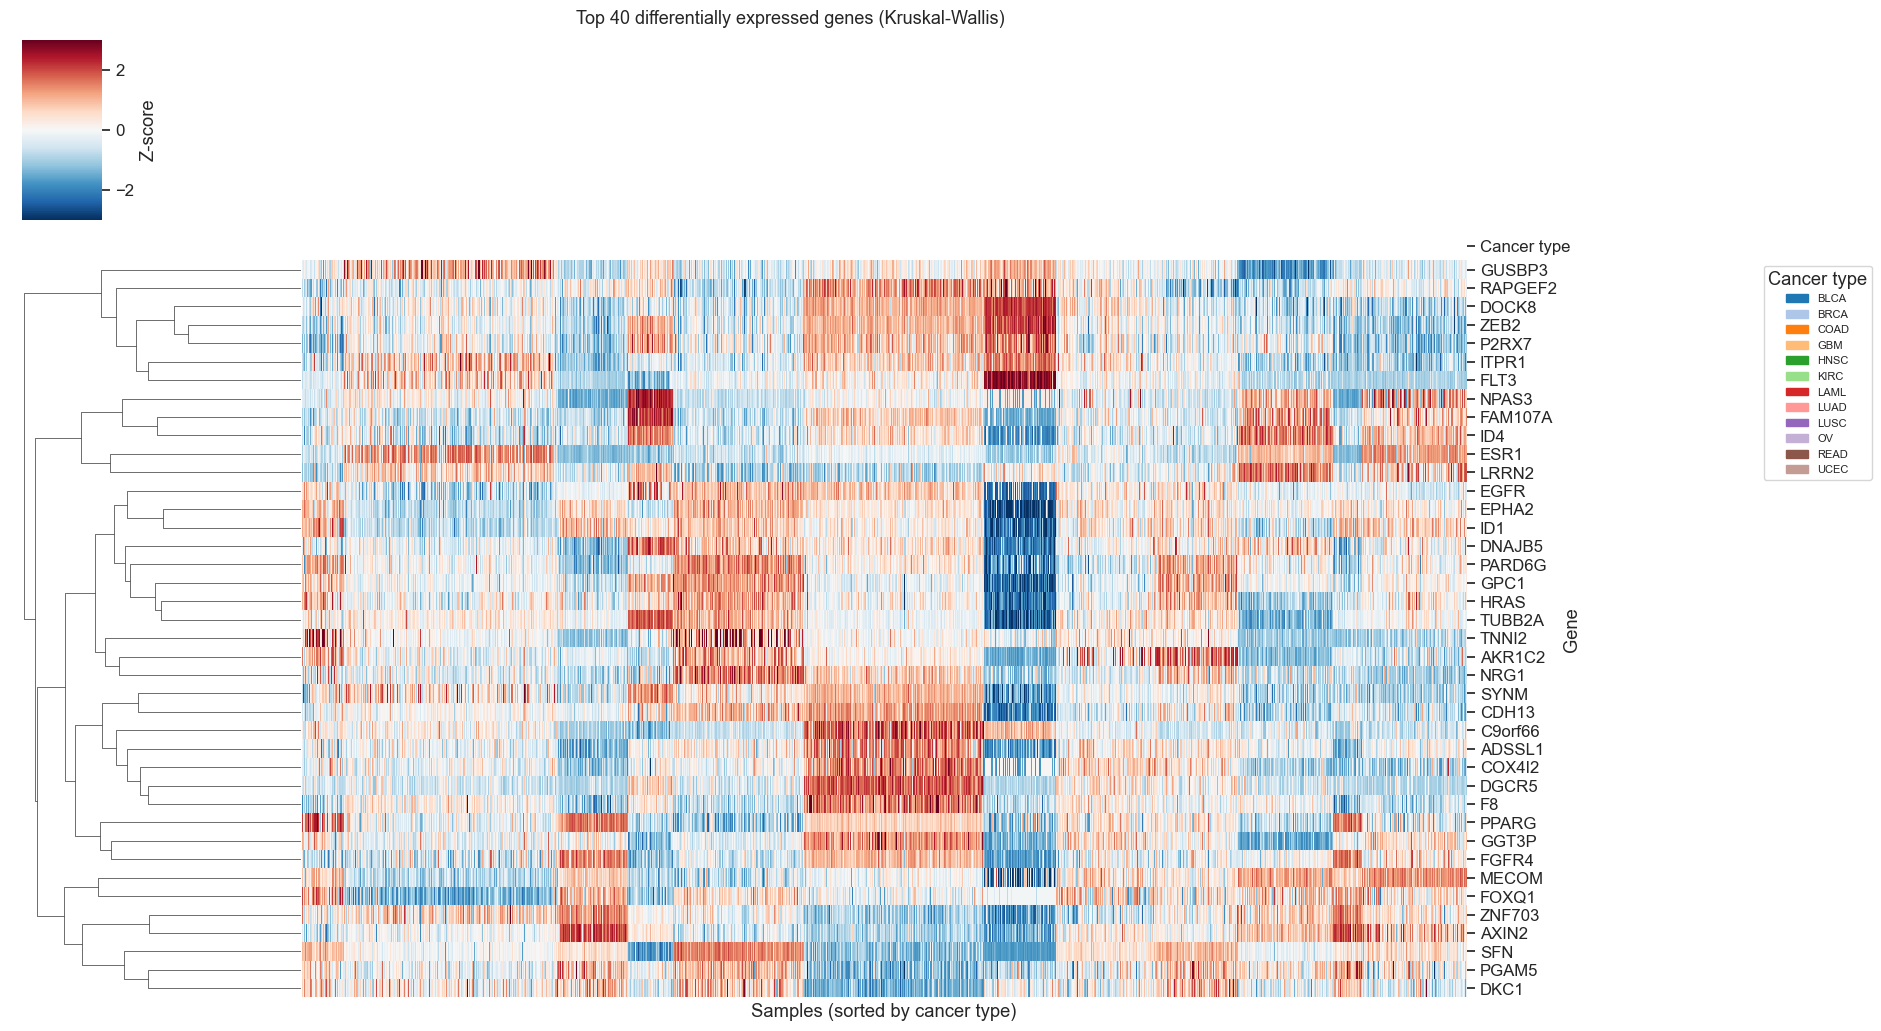

In [7]:
N_DE = 40   # top DE genes to show in heatmap

top_de_genes = kw_df.head(N_DE)["gene"].tolist()
ge_de = ge_hvg[top_de_genes]

# Z-score across samples
ge_de_z = (ge_de - ge_de.mean()) / ge_de.std()

# Sort samples by cancer type for the heatmap
sort_idx  = np.argsort(cancer_labels)
ge_de_sorted = ge_de_z.iloc[sort_idx]
ct_sorted    = cancer_labels[sort_idx]

# Cancer-type colour bar
row_colors = pd.Series(ct_sorted, name="Cancer type").map(ct_color)

g = sns.clustermap(
    ge_de_sorted.T,
    col_cluster=False,
    row_cluster=True,
    col_colors=row_colors,
    cmap="RdBu_r",
    vmin=-3, vmax=3,
    xticklabels=False,
    yticklabels=True,
    figsize=(16, 10),
    cbar_kws={"label": "Z-score"},
)
g.ax_heatmap.set_xlabel("Samples (sorted by cancer type)")
g.ax_heatmap.set_ylabel("Gene")
g.fig.suptitle(f"Top {N_DE} differentially expressed genes (Kruskal-Wallis)", y=1.01, fontsize=13)

# Legend for cancer types
handles = [mpatches.Patch(color=ct_color[t], label=t) for t in cancer_types]
g.ax_heatmap.legend(handles=handles, title="Cancer type", bbox_to_anchor=(1.25, 1),
                    loc="upper left", fontsize=8)
plt.show()


## 7 · PCA of Gene Expression

PCA on the HVG matrix reveals the main axes of variation.  
- **Scree plot**: how many PCs are needed before variance levels off (the "elbow")?  
- **PC1 vs PC2 scatter**: do cancer types separate?

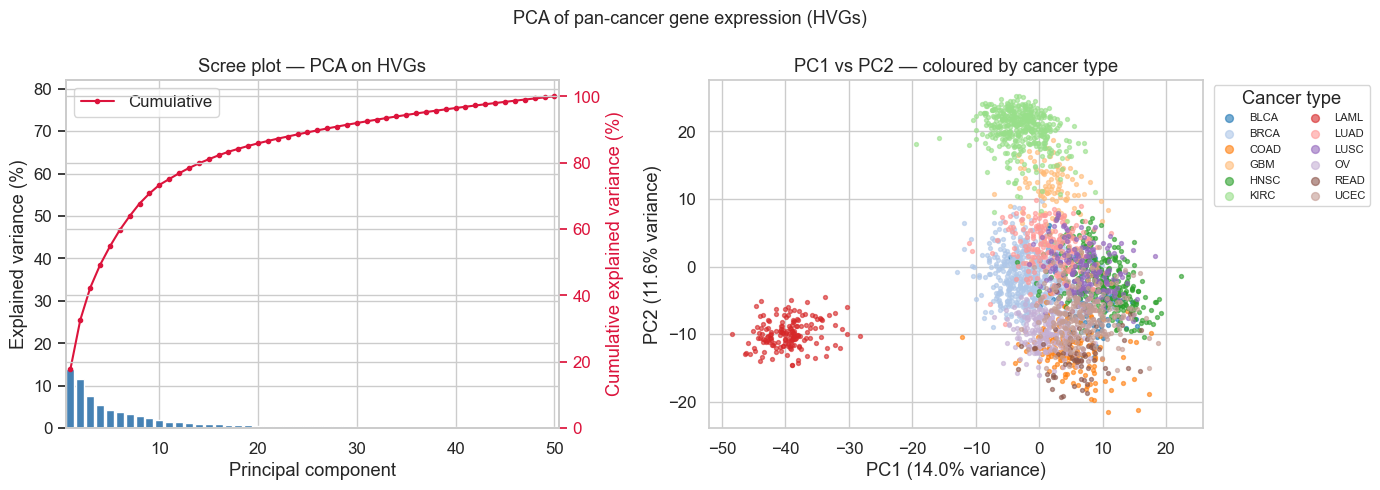

Variance explained: PC1=13.96%, PC2=11.58%, PC3=7.54%
Cumulative (10 PCs): 57.33%
Cumulative (50 PCs): 78.21%


In [8]:
N_PCS = 50

pca = PCA(n_components=N_PCS, random_state=42)
ge_pca = pca.fit_transform(ge_hvg.values)
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, N_PCS + 1), evr * 100, color="steelblue", edgecolor="white")
ax.plot(range(1, N_PCS + 1), np.cumsum(evr) * 100, color="crimson", marker="o",
        markersize=3, linewidth=1.5, label="Cumulative")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree plot — PCA on HVGs")
ax.legend()
ax.set_xlim(0.5, N_PCS + 0.5)
ax2 = ax.twinx()
ax2.set_ylabel("Cumulative explained variance (%)", color="crimson")
ax2.tick_params(axis="y", colors="crimson")
ax2.set_ylim(0, 105)

# PC1 vs PC2
ax = axes[1]
for t in cancer_types:
    mask = cancer_labels == t
    ax.scatter(ge_pca[mask, 0], ge_pca[mask, 1],
               s=8, alpha=0.6, color=ct_color[t], label=t)
ax.set_xlabel(f"PC1 ({evr[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({evr[1]:.1%} variance)")
ax.set_title("PC1 vs PC2 — coloured by cancer type")
ax.legend(markerscale=2, fontsize=8, title="Cancer type", ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("PCA of pan-cancer gene expression (HVGs)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Variance explained: PC1={evr[0]:.2%}, PC2={evr[1]:.2%}, PC3={evr[2]:.2%}")
print(f"Cumulative (10 PCs): {evr[:10].sum():.2%}")
print(f"Cumulative (50 PCs): {evr.sum():.2%}")


## 8 · t-SNE Visualisation

t-SNE is run on the first 50 PCA components. It is stochastic and non-linear — good for visualising local cluster structure but distances between clusters are not interpretable.

Running t-SNE on 50 PCs (may take ~1 min)...
Done.


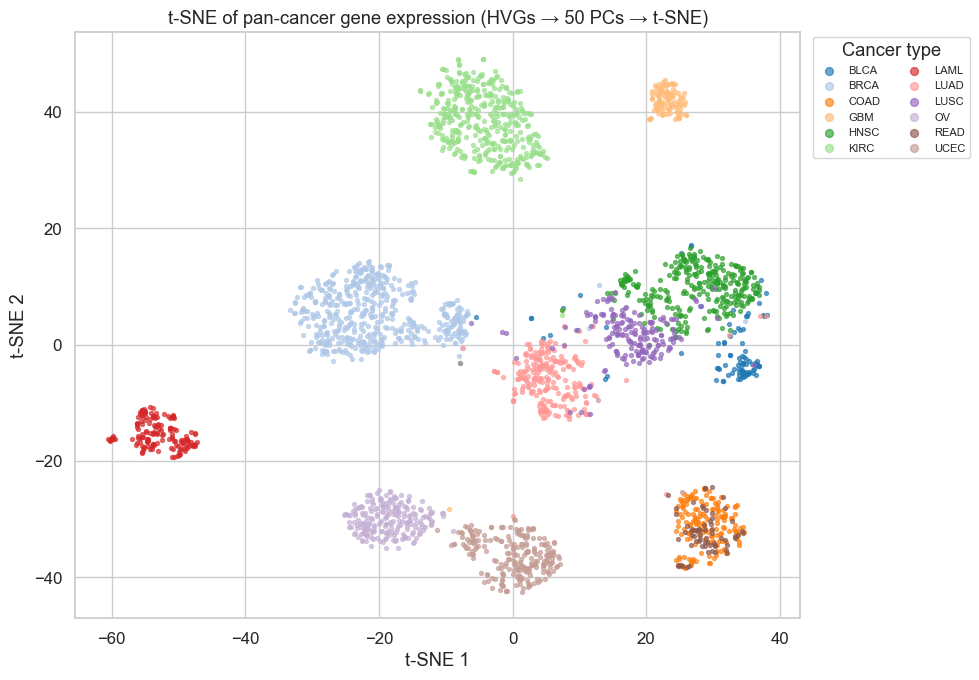

In [9]:
print("Running t-SNE on 50 PCs (may take ~1 min)...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
tsne_coords = tsne.fit_transform(ge_pca)
print("Done.")

fig, ax = plt.subplots(figsize=(10, 7))
for t in cancer_types:
    mask = cancer_labels == t
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               s=8, alpha=0.65, color=ct_color[t], label=t)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of pan-cancer gene expression (HVGs → 50 PCs → t-SNE)")
ax.legend(markerscale=2, fontsize=8, title="Cancer type", ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9 · Correlation Heatmap of Cancer Types

Pearson correlation between the **median HVG expression profiles** of each cancer type. High correlation means the two cancer types have similar transcriptional programmes. This is displayed as a clustered heatmap (clustermap), which groups similar cancer types together.

C:\Users\jonanord\AppData\Local\Temp\ipykernel_1344\3713785303.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ge_hvg.assign(cancer=cancer_labels)


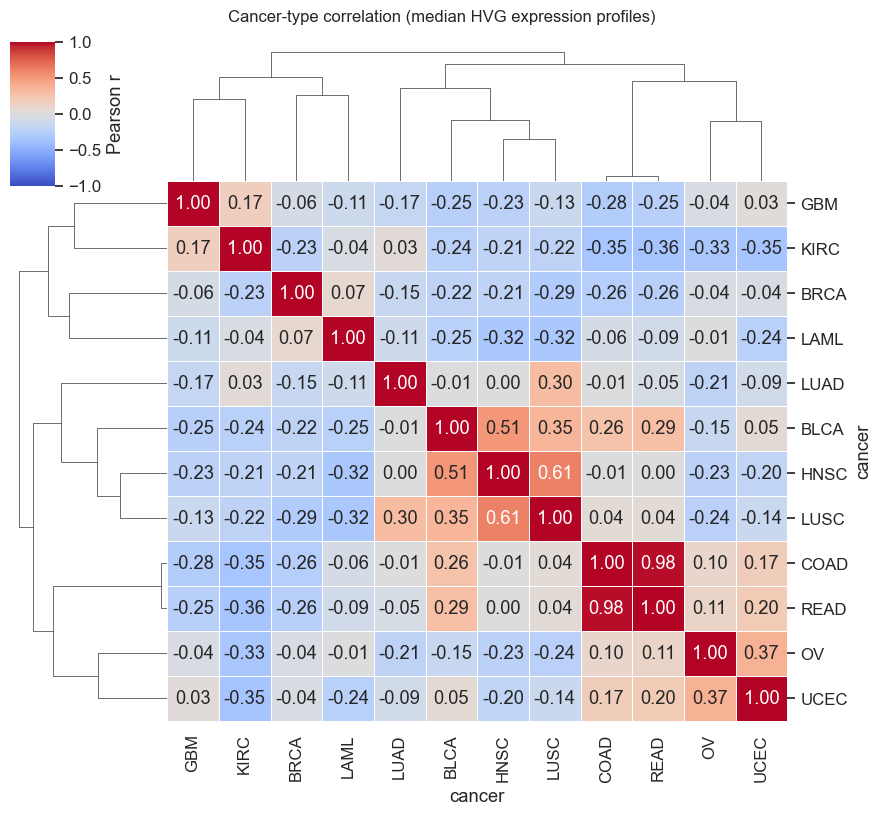


Most correlated pairs:


ValueError: cannot insert cancer, already exists

In [10]:
# Median HVG expression profile per cancer type
median_profiles = (
    ge_hvg.assign(cancer=cancer_labels)
    .groupby("cancer")
    .median()
)   # shape: (n_cancer_types, N_HVG)

# Pairwise Pearson correlation between cancer-type profiles
corr_ct = median_profiles.T.corr()

g = sns.clustermap(
    corr_ct,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    figsize=(9, 8),
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"},
)
g.fig.suptitle("Cancer-type correlation (median HVG expression profiles)", y=1.02, fontsize=12)
plt.show()

print("\nMost correlated pairs:")
corr_flat = (
    corr_ct.where(np.tril(np.ones(corr_ct.shape), k=-1).astype(bool))
    .stack()
    .rename("r")
    .reset_index()
    .rename(columns={"level_0": "type_A", "level_1": "type_B"})
    .sort_values("r", ascending=False)
)
print(corr_flat.head(10).to_string(index=False))


## 10 · Expression-Based Patient Stratification

For a selected gene (default: the most differentially expressed gene), split samples into **high-expression** and **low-expression** halves by the per-cancer-type median. We also do the same using **PC1 score**, which captures the dominant axis of variation across all HVGs.

This is a proxy for the kind of patient stratification commonly used in survival analysis (e.g., high vs low expressors of a marker gene).

Stratification gene: NPAS3


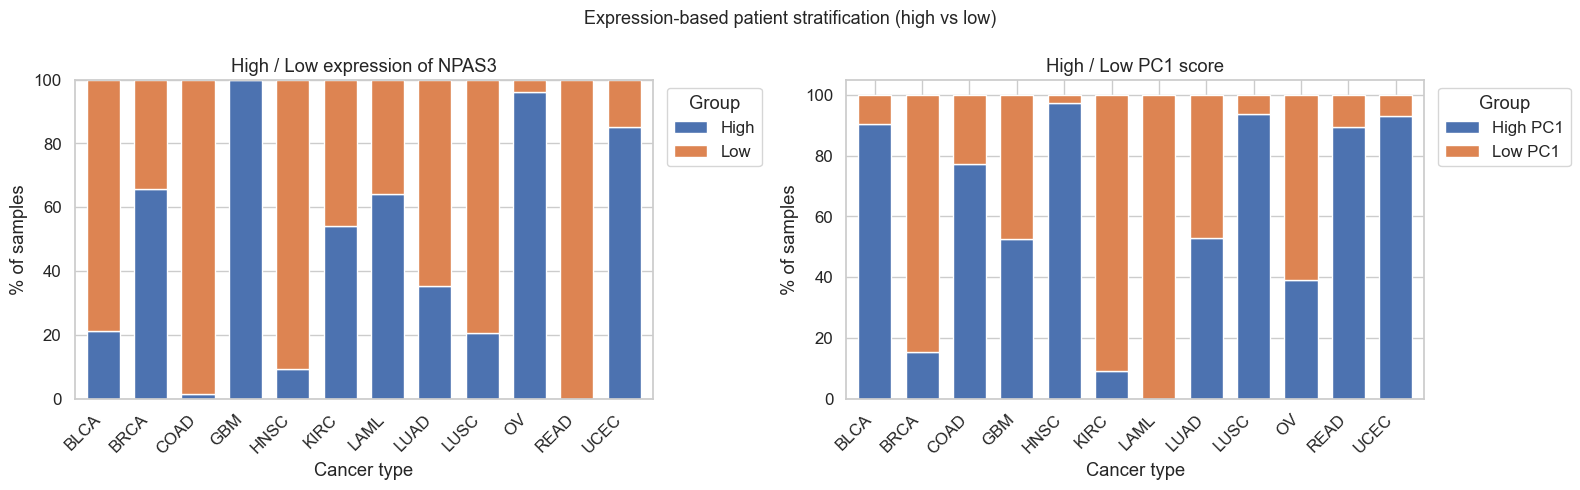

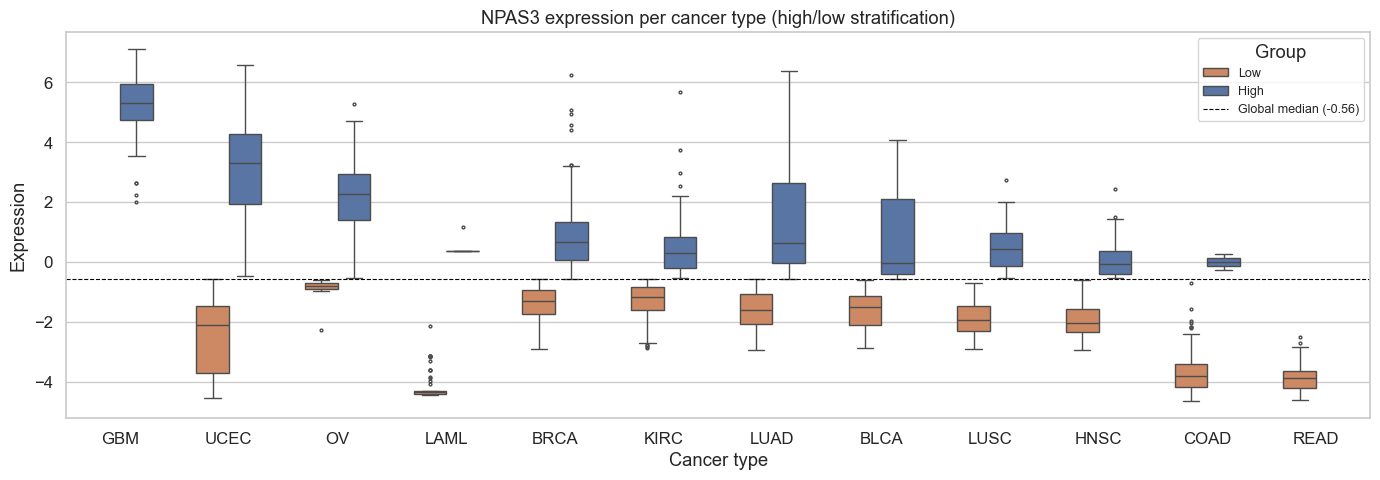

In [11]:
STRAT_GENE = kw_df.iloc[0]["gene"]   # most DE gene; change to any gene of interest
print(f"Stratification gene: {STRAT_GENE}")

strat_df = pd.DataFrame({
    "cancer":     cancer_labels,
    "expr":       ge_hvg[STRAT_GENE].values,
    "pc1":        ge_pca[:, 0],
})

global_median_expr = strat_df["expr"].median()
global_median_pc1  = strat_df["pc1"].median()

strat_df["group_gene"] = np.where(strat_df["expr"] >= global_median_expr, "High", "Low")
strat_df["group_pc1"]  = np.where(strat_df["pc1"] >= global_median_pc1,  "High PC1", "Low PC1")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gene-based stratification: stacked bar per cancer type
for ax, col, title in [
    (axes[0], "group_gene", f"High / Low expression of {STRAT_GENE}"),
    (axes[1], "group_pc1",  "High / Low PC1 score"),
]:
    ct_tab = pd.crosstab(strat_df["cancer"], strat_df[col], normalize="index") * 100
    ct_tab.plot(kind="bar", stacked=True, ax=ax,
                color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.7)
    ax.set_xlabel("Cancer type")
    ax.set_ylabel("% of samples")
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Expression-based patient stratification (high vs low)", fontsize=13)
plt.tight_layout()
plt.show()

# Boxplot: stratification gene expression per cancer type, split by group
fig, ax = plt.subplots(figsize=(14, 5))
ct_order = strat_df.groupby("cancer")["expr"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=strat_df, x="cancer", y="expr", order=ct_order,
            hue="group_gene", palette={"High": "#4C72B0", "Low": "#DD8452"},
            width=0.6, fliersize=2, ax=ax)
ax.axhline(global_median_expr, color="black", linestyle="--", linewidth=0.8,
           label=f"Global median ({global_median_expr:.2f})")
ax.set_xlabel("Cancer type")
ax.set_ylabel("Expression")
ax.set_title(f"{STRAT_GENE} expression per cancer type (high/low stratification)")
ax.legend(title="Group", fontsize=9)
plt.tight_layout()
plt.show()
